In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, glob, datetime
import xwmt, xwmb, xgcm, regionate, xbudget

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import pandas as pd

dpi = 150
mpl.rcParams['figure.dpi'] = dpi
sns.set_theme(context='notebook', style='ticks')

sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

from SWMT_decomposition import *
from ant_plots import *
from isopycnal_plot_formatting import *
from select_max_loc import *
from spatial_decompostion import *

In [2]:
def get_variable_spatial_decompose(mean_swmt, var = "SWMT"): 
    ds_decomp = decompose_discrete_full(
    mean_swmt[reference_period][var], mean_swmt[pert_period][var],
    dims=("xh", "yh"))
    return ds_decomp

def get_variable_spatial_sum_reference(mean_swmt, var = "SWMT"): 
    return mean_swmt[reference_period][var].sum(dim=("xh", "yh"))
    
def get_variable_spatial_sum_pert(mean_swmt, var = "SWMT"): 
    return mean_swmt[pert_period][var].sum(dim=("xh", "yh"))
    
def get_variable_integrand_change(mean_swmt, var = "SWMT"): 
    ds_decomp = get_variable_spatial_decompose(mean_swmt, var)
    return ds_decomp["integrand_change"]

def add_bar_numbers(bars, ax, text_height_factor = 2):
    # Grab the color of the bars so we can make the
    # text the same color.
    
    
    # Add text annotations to the top of the bars.
    # Note, you'll have to adjust this slightly (the 0.3)
    # with different data.
    for bar in bars:
        bar_color = bar.get_facecolor()
        height_diff = np.sign(bar.get_height()) * text_height_factor
        ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() + height_diff,
          round(bar.get_height(), 2),
          horizontalalignment='center',
          color=bar_color,
          weight='bold'
    )
        
# Define your custom seasons (example: tropical wet/dry seasons)
def custom_seasons(month):
    """Define custom seasons based on month"""
    if month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:  # May, June, July, AUgust
        return 'winter'
    else:
        return 'not_winter'

daterange2tuple = lambda x: tuple(map(int, x.split('-')))

In [3]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/notebooks/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='50GB',
    walltime='04:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=12)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/notebooks/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=47G
#SBATCH -t 04:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.61:40679 --name dummy-name --nthreads 36 --memory-limit 46.57GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.61:40679,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Load in data

In [4]:
reference_period = '1900-2000'
pert_period = '2090-2100'
expt_colors = dict(); expt_colors["control"] = "#2f74b3"; expt_colors["forced"] = "#cc415a"
toTg = 1e-9 

In [13]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x

ds = xr.open_dataset(datadir("/model/Southern_Ocean_DSW_1000m_WMT_Budget.zarr"), engine = "zarr")
ds_monthly_SWMT = get_SWMT(ds)

ds = ds.groupby("time.year").mean("time")
ds_SWMT = get_SWMT(ds)
ds["surface_boundary_fluxes"] = ds["boundary_fluxes"] - ds["bottom_flux_heat"]

In [27]:
abyssal_sbf = ds.sel(sigma2_l_target = slice(20, 38.1))["surface_boundary_fluxes"].fillna(0.0)
max_locations = abyssal_sbf.argmax("sigma2_l_target")

control_max = abyssal_sbf["sigma2_l_target"][max_locations.sel(exp = "control")].rename("max_surface_boundary_flux_density")
forced_max = abyssal_sbf["sigma2_l_target"][max_locations.sel(exp = "forced")].rename("max_surface_boundary_flux_density")

max_sbf_loc = xr.concat([control_max, forced_max], dim = "exp")
max_sbf = select_from_location(abyssal_sbf, max_sbf_loc)

max_sbf_and_loc = xr.merge([max_sbf_loc, max_sbf], compat='override')

max_sbf_and_loc["surface_boundary_fluxes"].attrs = {"units":"Tg/s"}

max_sbf_and_loc.to_zarr(savedir + "Southern_Ocean_DSW_1000m_max_SWMT.zarr", mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [32]:
abyssal_export = ds.sel(sigma2_l_target = slice(20, 38.1))["convergent_mass_transport"].fillna(0.0)
max_locations = abyssal_export.argmin("sigma2_l_target")

control_max = abyssal_export["sigma2_l_target"][max_locations.sel(exp = "control")].rename("max_export_density")
forced_max = abyssal_export["sigma2_l_target"][max_locations.sel(exp = "forced")].rename("max_export_density")

max_export_loc = xr.concat([control_max, forced_max], dim = "exp")
max_export = select_from_location(abyssal_export, max_export_loc)

max_export_and_loc = xr.merge([max_export_loc, max_export], compat='override')

max_export_and_loc["convergent_mass_transport"].attrs = {"units":"Tg/s"}

max_export_and_loc.to_zarr(savedir + "Southern_Ocean_DSW_1000m_max_export.zarr", mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


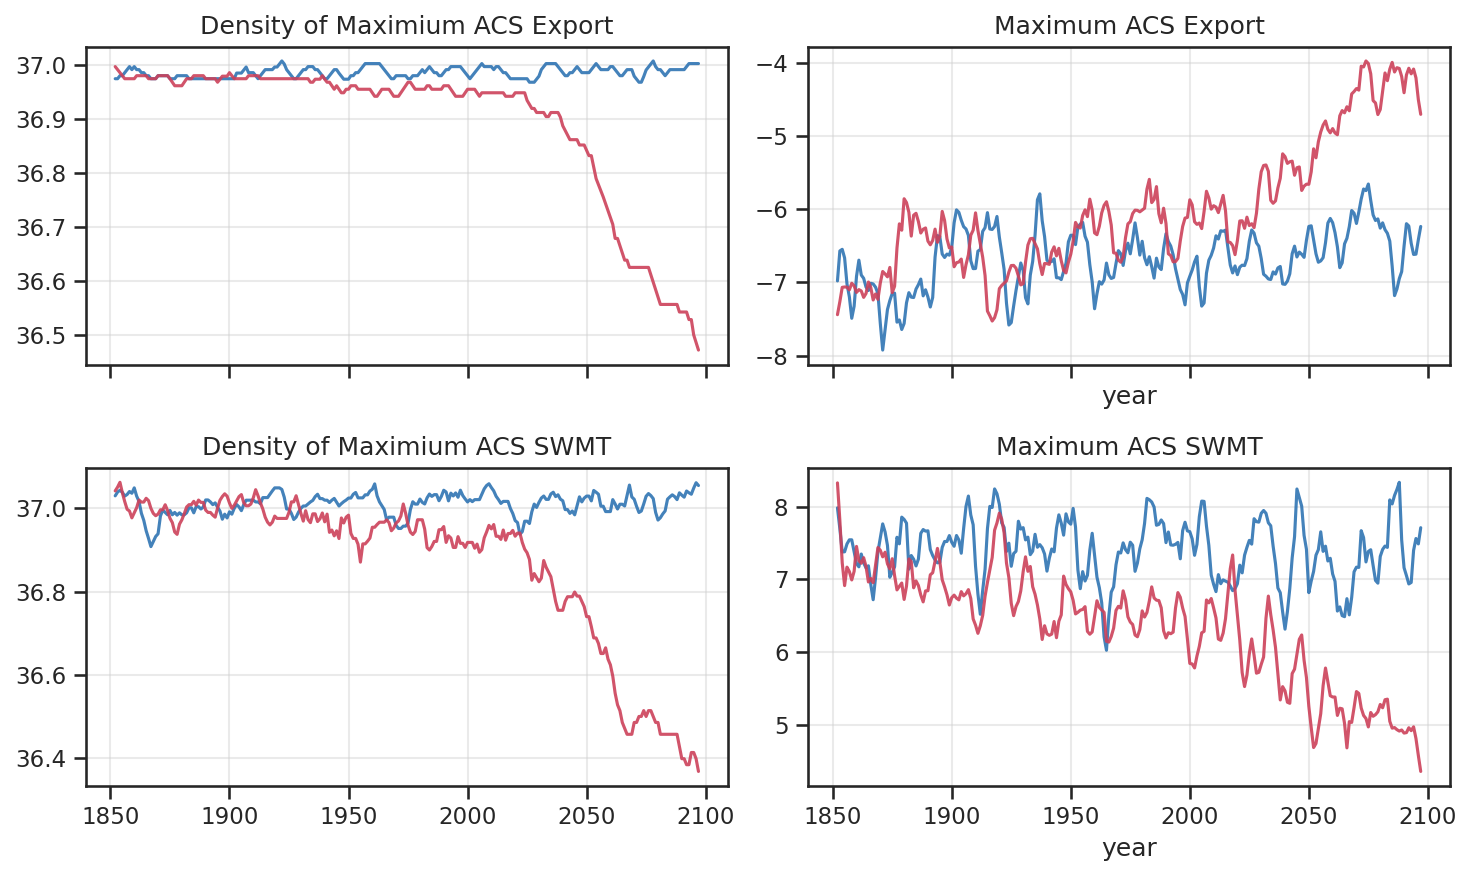

In [37]:
#PLOTTING 
year_rolling = 5
fig, axes = plt.subplots(2, 2, figsize = (10, 6), sharex = True)

ax = axes[0, :]
max_export_loc_rolling = max_export_loc.rolling(year=year_rolling, center=True).mean().dropna("year")
expts = ["control", "forced"]
expt_labels = ["Control", "Historical/SSP585"]
for (i, expt) in enumerate(expts):
    max_export_loc_rolling.sel(exp =expt).plot(ax = ax[0], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[0].set_ylabel(r"")
ax[0].set_title("Density of Maximium ACS Export")
ax[0].grid(zorder = 0, alpha = 0.4)
ax[0].set_xlabel("")

max_export_rolling = toTg * max_export.rolling(year=year_rolling, center=True).mean().dropna("year")
for (i, expt) in enumerate(expts):
    max_export_rolling.sel(exp =expt).plot(ax = ax[1], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[1].set_ylabel(r"")
ax[1].grid(zorder = 0, alpha = 0.4)

ax[1].set_title("Maximum ACS Export")

ax = axes[1, :]
max_sbf_loc_rolling = max_sbf_loc.rolling(year=year_rolling, center=True).mean().dropna("year")
expts = ["control", "forced"]
expt_labels = ["Control", "Historical/SSP585"]
for (i, expt) in enumerate(expts):
    max_sbf_loc_rolling.sel(exp =expt).plot(ax = ax[0], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[0].set_ylabel(r"")
ax[0].set_title("Density of Maximium ACS SWMT")
ax[0].grid(zorder = 0, alpha = 0.4)
ax[0].set_xlabel("")

max_sbf_rolling = toTg * max_sbf.rolling(year=year_rolling, center=True).mean().dropna("year")
for (i, expt) in enumerate(expts):
    max_sbf_rolling.sel(exp =expt).plot(ax = ax[1], c = expt_colors[expt], label = expt_labels[i], alpha = .9)
ax[1].set_ylabel(r"")
ax[1].grid(zorder = 0, alpha = 0.4)

ax[1].set_title("Maximum ACS SWMT")

fig.tight_layout()

In [38]:
ds_sfc = xr.open_mfdataset(datadir(f"/model/Southern_Ocean_DSW_1000m_WMT_Surface_Fluxes_sigma_slice.zarr"))
ds_sfc_SWMT = get_SWMT(ds_sfc)
ds_sfc_SWMT["SWMT_residual"] = ds_sfc_SWMT["SWMT_heat_residual"] + ds_sfc_SWMT["SWMT_salt_residual"]

sbf_max_densities = max_sbf_and_loc[["max_surface_boundary_flux_density"]].isel(year = slice(0, -1))
ds_sfc_SWMT_cropped = ds_sfc_SWMT.isel(year = slice(0, -1))

ds_sfc_SWMT_fixed = select_from_location2(ds_sfc_SWMT_cropped, sbf_max_densities) 

mass_flux_units_conversion = toTg / (ds_sfc_SWMT.areacello)
mass_flux_units = r"$Tg/s / m^2$"
mass_flux_units_string = "Tg/s / m^2"

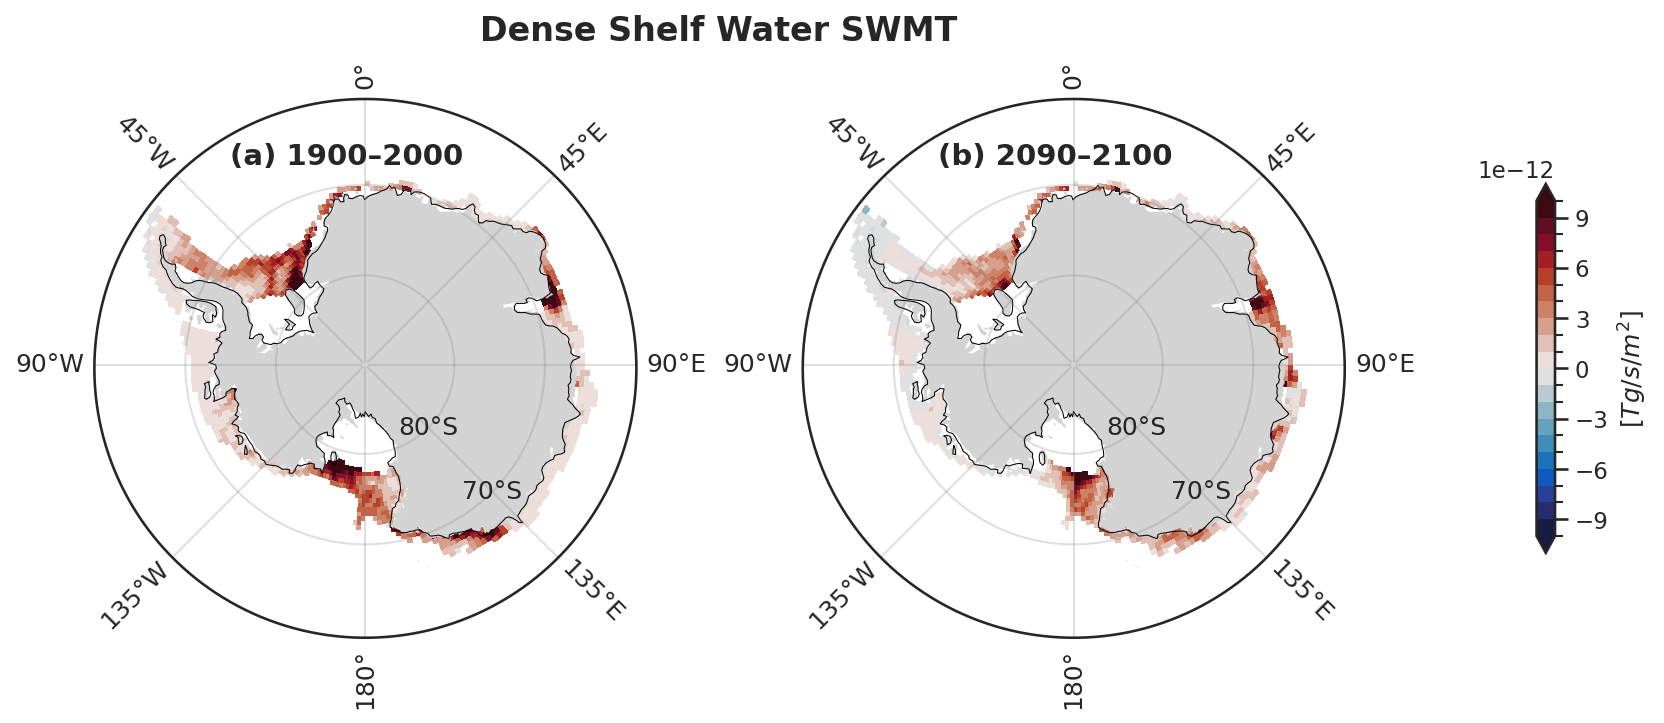

In [39]:
scale = 1
density_title = f""
cmap = cmo.balance; plt.get_cmap('Spectral_r')
boundaries = 1e-12 * np.arange(-10, 10 + 0.1,1)
boundaries[np.abs(boundaries) < 1e-16]  = 0
norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

times_list = [daterange2tuple(reference_period), daterange2tuple(pert_period)]
nt = len(times_list)

fig, ax = plt.subplots(
    1, nt, figsize=(11, 5),
    subplot_kw={"projection": ccrs.SouthPolarStereo()},
    constrained_layout=True
)

for a in ax:
    a.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

panel_letters = ["(a) 1900–2000", "(b) 2090–2100"]

cm = None
mean_swmt = dict()

for i, times in enumerate(times_list):
    var = ds_sfc_SWMT_fixed.sel(year=slice(times[0], times[1])).sel(exp="forced").mean("year")
    var_masked = var.where(np.abs(var["SWMT"]) > 1100)
    mean_swmt['-'.join(list(map(str, times)))] = var_masked.compute()

    var_plot = (var_masked["SWMT"] * mass_flux_units_conversion) * scale
    cm = plot_antarctic(var_plot, ax[i], cmap=cmap, norm=norm, mask_threshold=1e-50)

    ax[i].text(
        0.25, 0.92, panel_letters[i],
        transform=ax[i].transAxes, ha="left", va="top",
        fontsize=14, fontweight="bold"
    )

fig.suptitle("Dense Shelf Water SWMT", fontsize=16, fontweight="bold", verticalalignment = "center", x = 0.43, y = 0.95)

cbar = fig.colorbar(cm, ax=ax, shrink=0.5, pad=0.05, extend="both")
cbar.set_label(r"[" + mass_flux_units + r"]")

In [40]:
keys = list(mean_swmt)
mean_swmt_ds = xr.concat(
    [mean_swmt[k] for k in keys],
    dim=xr.IndexVariable("period", keys),
)

for var in list(mean_swmt_ds.data_vars):
    mean_swmt_ds[var]["units"] = "Tg/s / m^2"
    
mean_swmt_ds.to_zarr(savedir + "DSW_SWMT_periods.zarr", mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [41]:
mean_swmt_dict = {
    str(k): mean_swmt_ds.sel(period=k).drop_vars("period")
    for k in mean_swmt_ds.coords["period"].values.tolist()
}
ds_diff_decomp = get_variable_spatial_decompose(mean_swmt_dict, var = "SWMT") 
ds_ref_sum = toTg * get_variable_spatial_sum_reference(mean_swmt_dict, var = "SWMT") 
ds_pert_sum =  toTg * get_variable_spatial_sum_pert(mean_swmt_dict, var = "SWMT") 

ds_diff_decomp.to_zarr(savedir + "DSW_SWMT_period_mask_differences.zarr", mode = "w")

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


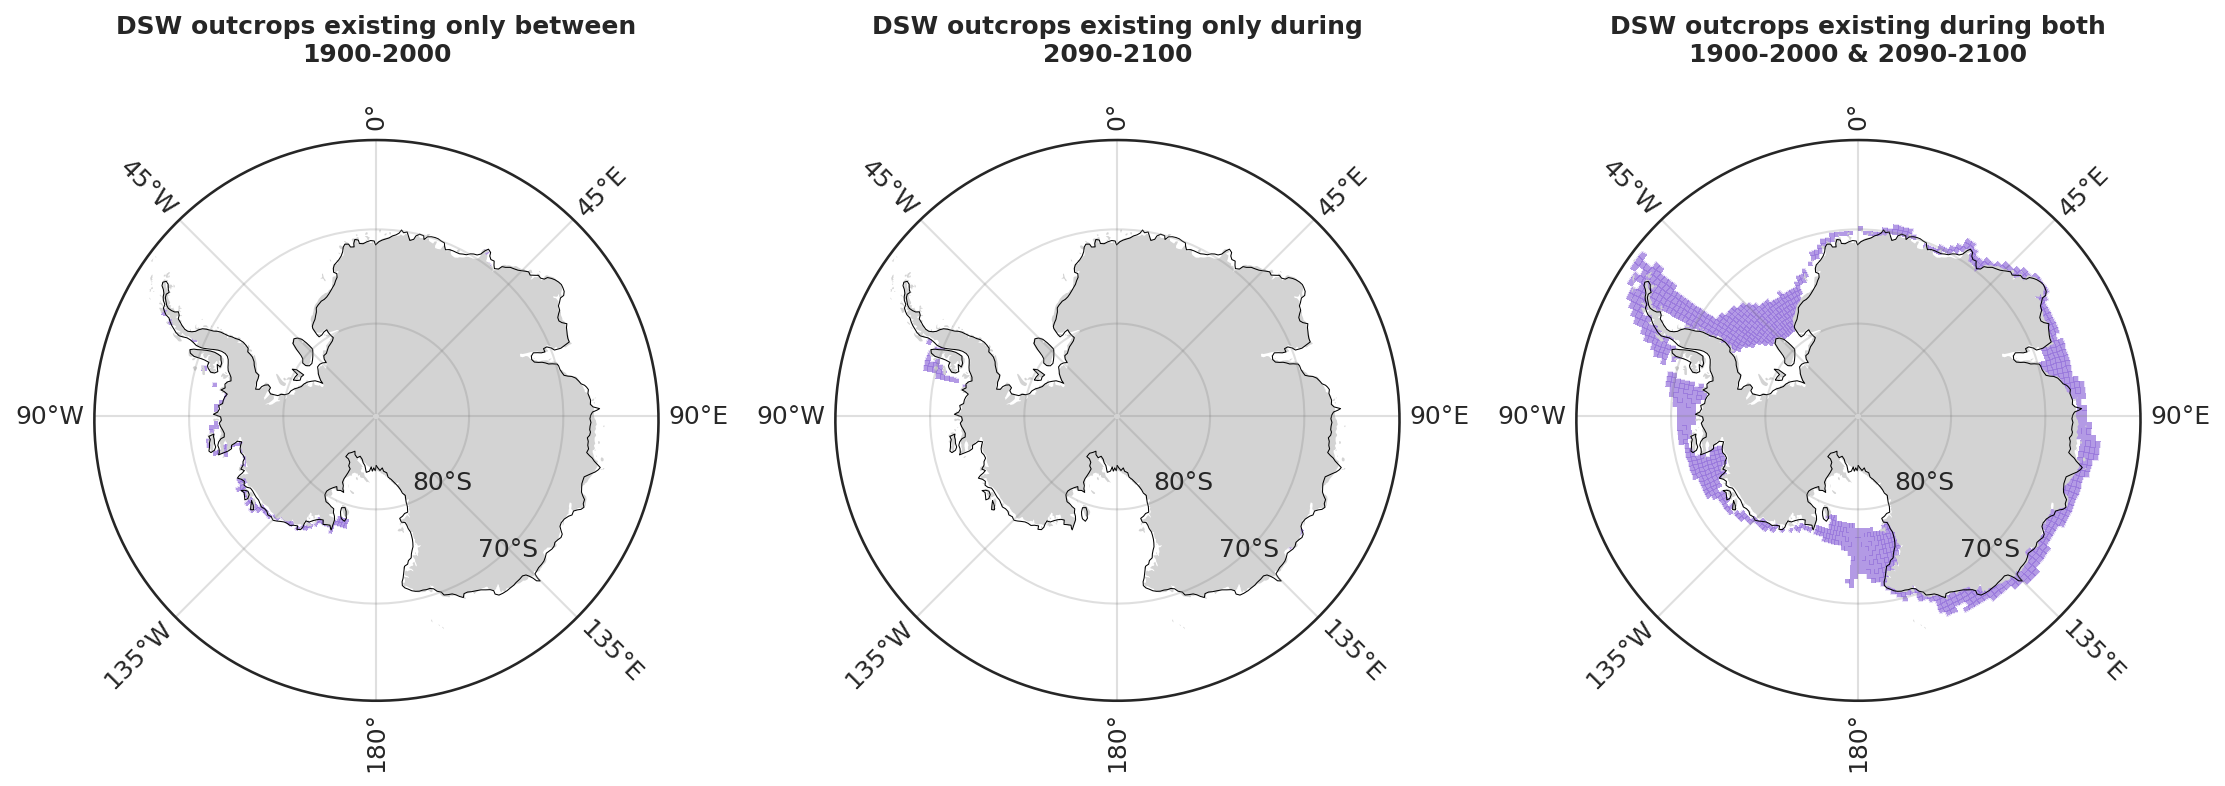

In [42]:
base = ListedColormap(['white','mediumpurple'])
colors = base(np.linspace(0, 1, base.N))
colors[:, -1] = 0.7        # set all alphas to
cmap = ListedColormap(colors)

regions = ["D_f_minus_g", "D_g_minus_f", "D_intersect"]
nr = len(regions)

fig, ax = plt.subplots(1, nr, figsize = (15, 5),
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})
[a.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()) for a in ax.flatten()]

for (i, region) in enumerate(regions):
    cm = plot_antarctic(1.0 * ds_diff_decomp[region], ax[i], 
                        cmap = cmap, norm = None, mask_threshold = -np.inf)
        


ax[0].set_title("DSW outcrops existing only between\n" + '-'.join(list(map(str, times_list[0]))) + "\n" + density_title, 
             fontweight = "bold", fontsize = 12, ha='center')

ax[1].set_title("DSW outcrops existing only during\n" + '-'.join(list(map(str, times_list[1]))) + "\n" + density_title, 
             fontweight = "bold", fontsize = 12, ha='center')


ax[2].set_title("DSW outcrops existing during both\n" + '-'.join(list(map(str, times_list[0]))) + " & " + '-'.join(list(map(str, times_list[1]))) + "\n" +  density_title, 
             fontweight = "bold", fontsize = 12, ha='center')

fig.tight_layout()

fig.savefig("plots/ASC_SWMT_Spatial_Differences.png", dpi = 250, bbox_inches = "tight")